# Scattering Properties of Cloud and Aerosol Particles Using Mie Code

## Install packages and load libraries

In [1]:
# !pip install miepython

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import miepython as mie

import warnings 
warnings.filterwarnings("ignore")   

## Simple test of Miepython

Document and Tutorial of miepython

https://miepython.readthedocs.io/en/latest/index.html


In [3]:
os.environ["MIEPYTHON_USE_JIT"] = "1"  # Must be set before importing

In [4]:
m = 1.5 - 1j       # Complex refractive index
d = 100            # Diameter (nm)
lambda0 = 314.15   # Wavelength in vacuum (nm)

# Calculate efficiencies
qext, qsca, qback, g = mie.efficiencies(m, d, lambda0)

print(f"Extinction efficiency:  {qext:.3f}")
print(f"Scattering efficiency:  {qsca:.3f}")
print(f"Backscatter efficiency: {qback:.3f}")
print(f"Scattering anisotropy:  {g:.3f}")

Extinction efficiency:  2.336
Scattering efficiency:  0.663
Backscatter efficiency: 0.573
Scattering anisotropy:  0.192


## Fetch Refractive index of water from online database
Read the water refractive index from the URL "https://refractiveindex.info/tmp/database/data/main/H2O/nk/Hale.txt", which contains two sections: one for wavelength and the real part of the refractive index, and another for wavelength and the imaginary part.

In [5]:
import requests

url = "https://refractiveindex.info/tmp/database/data/main/H2O/nk/Hale.txt"
response = requests.get(url)

if response.status_code == 200:
    file_content = response.text
    print("File content downloaded successfully.")
else:
    print(f"Failed to download file. Status code: {response.status_code}")

File content downloaded successfully.


In [6]:
lines = file_content.strip().split('\n')

separator_index = -1
for i, line in enumerate(lines):
    parts = line.split()
    if len(parts) != 2 or not parts[0].replace('.', '', 1).isdigit() or not parts[1].replace('.', '', 1).isdigit():
        '''
        This line is not a data line with two numbers. It could be a header or the start of the next section.
        If we've already passed the initial header (assuming the first line is a header), this is likely the separator.
        '''
        if i > 0:
            separator_index = i
            break

if separator_index != -1:
    # Assuming the first line is a header for the first section
    section1_lines = [line for i, line in enumerate(lines) if i > 0 and i < separator_index and not line.startswith('#')]
    
    # Assuming the line after the separator_index is a header for the second section
    section2_lines = [line for i, line in enumerate(lines) if i > separator_index + 1 and not line.startswith('#')]
    
    print(f"Sections separated successfully at line {separator_index}. Found {len(section1_lines)} lines for the first section and {len(section2_lines)} lines for the second section.")
else:
    '''
    If no such line is found, it's possible the two sections are just appended.
    In this case, we'll need to make an assumption about the number of lines in the first section,
    or look for a pattern shift. Without a clear pattern shift or separator,
    and based on the provided sample showing only 'n' data, it's difficult to definitively separate.
    Since I cannot ask for help, I will assume for now that the entire content is the first section
    and report that the separator was not found as expected. This is a failure to fully separate.
    '''
    section1_lines = [line for i, line in enumerate(lines) if i > 0 and not line.startswith('#')]
    section2_lines = []
    print("No clear separator found based on two-column numeric data. Assuming the entire content after the initial header belongs to the first section.")

Sections separated successfully at line 170. Found 169 lines for the first section and 169 lines for the second section.


### Extract data

#### Subtask:
Process each section to extract the wavelength and the corresponding real or imaginary part of the refractive index.


**Reasoning**:
Iterate through the lines of both `section1_lines` and `section2_lines`, extract and convert the wavelength and refractive index values to floats, and store them in separate lists as instructed.



In [7]:
wavelengths_n = []
n_values = []
for line in section1_lines:
    parts = line.split()
    if len(parts) == 2:
        try:
            wl = float(parts[0])
            n = float(parts[1])
            wavelengths_n.append(wl)
            n_values.append(n)
        except ValueError:
            # Skip lines that don't contain valid float pairs
            continue

wavelengths_k = []
k_values = []
for line in section2_lines:
    parts = line.split()
    if len(parts) == 2:
        try:
            wl = float(parts[0])
            k = float(parts[1])
            wavelengths_k.append(wl)
            k_values.append(k)
        except ValueError:
            # Skip lines that don't contain valid float pairs
            continue

print(f"Extracted {len(wavelengths_n)} wavelength and n values.")
print(f"Extracted {len(wavelengths_k)} wavelength and k values.")

Extracted 169 wavelength and n values.
Extracted 169 wavelength and k values.


Create pandas DataFrames from the extracted wavelength and refractive index values for both the real and imaginary parts.

In [8]:
# N = n+ik,   where k is absorption
df_n = pd.DataFrame({'Wavelength': wavelengths_n, 'n': n_values})

df_k = pd.DataFrame({'Wavelength': wavelengths_k, 'k': k_values})

display(df_n.head())
display(df_k.head())

,Wavelength,n
0,0.200,1.396
1,0.225,1.373
2,0.250,1.362
3,0.275,1.354
4,0.300,1.349


,Wavelength,k
0,0.200,1.100000e-07
1,0.225,4.900000e-08
2,0.250,3.350000e-08
3,0.275,2.350000e-08
4,0.300,1.600000e-08


In [9]:
df_merged = pd.merge(df_n, df_k, on='Wavelength')
display(df_merged.head())

,Wavelength,n,k
0,0.200,1.396,1.100000e-07
1,0.225,1.373,4.900000e-08
2,0.250,1.362,3.350000e-08
3,0.275,1.354,2.350000e-08
4,0.300,1.349,1.600000e-08


In [10]:
df_filtered = df_merged[(df_merged['Wavelength'] >= 0.2) & (df_merged['Wavelength'] <= 3.0)]
display(df_filtered.head())

,Wavelength,n,k
0,0.200,1.396,1.100000e-07
1,0.225,1.373,4.900000e-08
2,0.250,1.362,3.350000e-08
3,0.275,1.354,2.350000e-08
4,0.300,1.349,1.600000e-08


### Visualize data


Plot showing both the real ('n') and imaginary ('k') parts of the refractive index against wavelength.


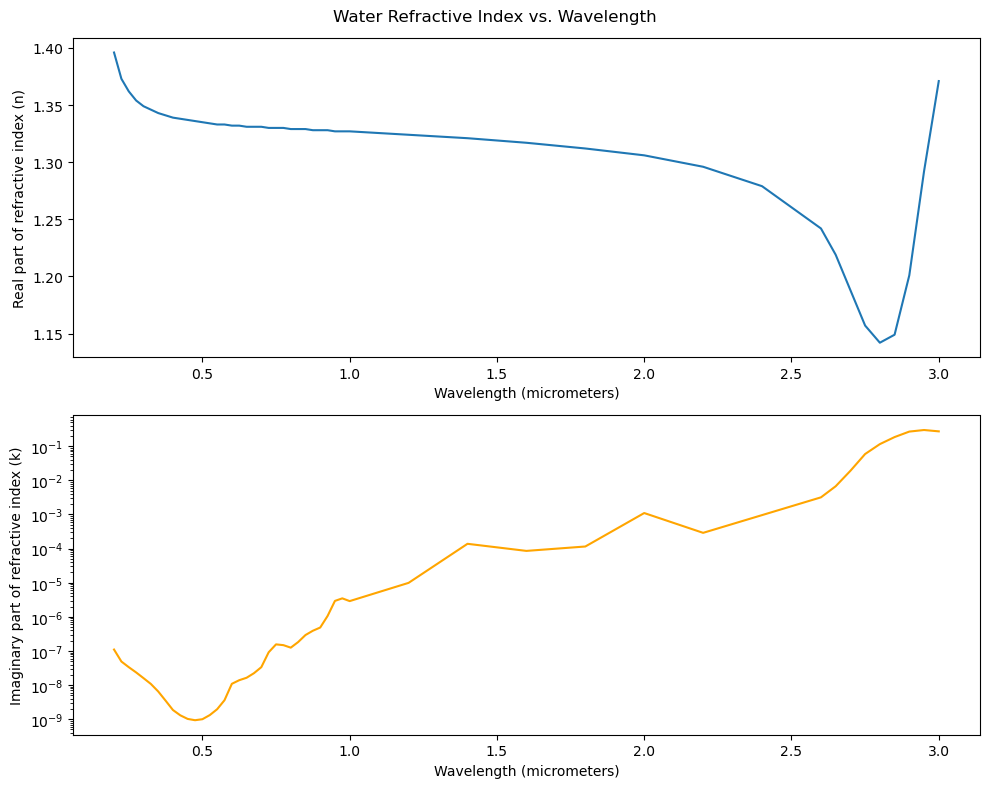

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(df_filtered['Wavelength'], df_filtered['n'])
ax1.set_xlabel('Wavelength (micrometers)')
ax1.set_ylabel('Real part of refractive index (n)')

ax2.plot(df_filtered['Wavelength'], df_filtered['k'], color='orange')
ax2.set_xlabel('Wavelength (micrometers)')
ax2.set_ylabel('Imaginary part of refractive index (k)')
ax2.set_yscale('log')

fig.suptitle('Water Refractive Index vs. Wavelength')
plt.tight_layout()
plt.show()

## Compute the Scattering properties of water droplet

In [12]:
Water_Ref = df_filtered
def Refractive_Index_Interp(Water_Ref, Wl_nm):
    """
    Interpolates the water refractive index (n + ik) for a given wavelength or array of wavelengths.

    Args:
        Wl: A single wavelength or a numpy array of wavelengths in micrometers.

    Returns:
        A complex number or a numpy array of complex numbers representing the
        interpolated refractive index at the given wavelength(s).
    """
    interp_n = np.interp(Wl_nm*1e-3, Water_Ref['Wavelength'], Water_Ref['n'])
    interp_k = np.interp(Wl_nm*1e-3, Water_Ref['Wavelength'], Water_Ref['k'])

    return interp_n - 1j * interp_k

## Compute the scalar scattering properties: Qe, Qs, g-factor

In [13]:
Wl = np.array([470,550,670])
Ref = Refractive_Index_Interp(Water_Ref, Wl)
print(Ref)

Cloud_Scattering_Prop ={'R':{},'G':{},'B':{}}
wavelengths = [Wl[0], Wl[1], Wl[2]]
refs = [Ref[0], Ref[1], Ref[2]]
colors = ['B', 'G', 'R']

diameterRange = (200,200000)     # (100,300000)
nD = 2000     # 500
# d = np.logspace(np.log10(diameterRange[0]), np.log10(diameterRange[1]), nD)
d = np.linspace(diameterRange[0], diameterRange[1], nD)

for i, color in enumerate(colors):
    Cloud_Scattering_Prop[color]['Wl'] = wavelengths[i]
    Cloud_Scattering_Prop[color]['Ref'] = refs[i]

    qext, qsca, qback, g = mie.efficiencies(refs[i], d, wavelengths[i])

    Cloud_Scattering_Prop[color]['D'] =d
    Cloud_Scattering_Prop[color]['qext'] = qext
    Cloud_Scattering_Prop[color]['qsca'] = qsca
    Cloud_Scattering_Prop[color]['g'] = g

[1.3362-9.520e-10j 1.333 -1.960e-09j 1.331 -2.112e-08j]


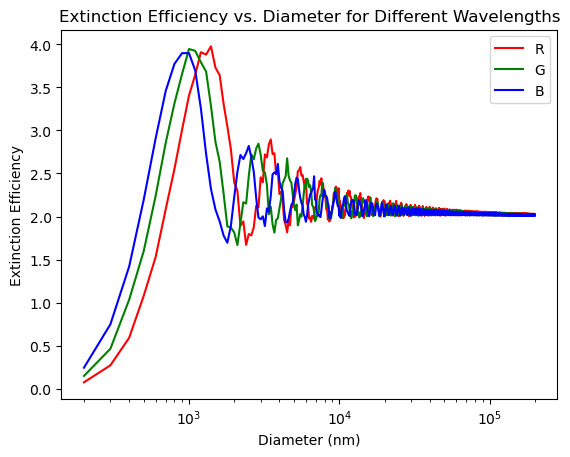

In [14]:
fig, ax=plt.subplots()
color_map = {'R': 'r', 'G': 'g', 'B': 'b'}     # Create a dictionary to map colors
for color, data in Cloud_Scattering_Prop.items():
    ax.plot(data['D'], data['qext'], color=color_map[color], label=color)     # Use the dictionary for color

ax.set_xscale('log')
ax.set_xlabel('Diameter (nm)')
ax.set_ylabel('Extinction Efficiency')
ax.set_title('Extinction Efficiency vs. Diameter for Different Wavelengths')
ax.legend()
plt.show()

## Compute Phase matrix

In [15]:
Ang = np.arange(0, 180, 0.25)
Mu  = np.cos(np.radians(Ang))

In [16]:
for i, color in enumerate(colors):
    print('processing', color)
    Cloud_Scattering_Prop[color]['Ang'] = Ang
    Cloud_Scattering_Prop[color]['Mu'] = Mu
    
    # Initialize dictionaries to store matrix elements for each diameter
    Cloud_Scattering_Prop[color]['PhaseFunction'] = np.array([])
    Cloud_Scattering_Prop[color]['DoLP'] = np.array([])
    Cloud_Scattering_Prop[color]['Theta'] = np.array([])

    m = Cloud_Scattering_Prop[color]['Ref']
    for diameter in Cloud_Scattering_Prop[color]['D']:
        # print('processing',diameter)
        x=np.pi*diameter/Cloud_Scattering_Prop[color]['Wl']
    
        S1, S2 = mie.S1_S2(m, x, Mu)
        S11 = (np.abs(S2) ** 2 + np.abs(S1) ** 2) / 2
        S12 = (np.abs(S2) ** 2 - np.abs(S1) ** 2) / 2
        Cloud_Scattering_Prop[color]['PhaseFunction']=np.append(Cloud_Scattering_Prop[color]['PhaseFunction'],np.array(S11))
        Cloud_Scattering_Prop[color]['DoLP']=np.append(Cloud_Scattering_Prop[color]['DoLP'],np.array(S12))

    Cloud_Scattering_Prop[color]['Theta']=np.array(Ang)
    Cloud_Scattering_Prop[color]['PhaseFunction']=np.reshape(Cloud_Scattering_Prop[color]['PhaseFunction'],(len(Cloud_Scattering_Prop[color]['D']),len(Ang)))
    Cloud_Scattering_Prop[color]['DoLP']=np.reshape(Cloud_Scattering_Prop[color]['DoLP'],(len(Cloud_Scattering_Prop[color]['D']),len(Ang)))

processing B
processing G
processing R


In [17]:
# Cloud_Scattering_Prop['B']['PhaseFunction'].shape
# print(Cloud_Scattering_Prop['R']['PhaseFunction'].max())

In [18]:
# fig, ax= plt.subplots()
# ax.plot(Cloud_Scattering_Prop['B']['Theta'], Cloud_Scattering_Prop['B']['PhaseFunction'][0,:], c='k',ls='solid')
# ax.plot(Cloud_Scattering_Prop['B']['Theta'], Cloud_Scattering_Prop['B']['PhaseFunction'][-1,:], c='k',ls='dashed')
# ax.set_yscale('log')
# ax.set_xlabel('Angle (degrees)')
# plt.show()

# fig,ax=plt.subplots()
# ax.plot(Cloud_Scattering_Prop['B']['Theta'],
#         Cloud_Scattering_Prop['B']['DoLP'][-1,:]/Cloud_Scattering_Prop['B']['PhaseFunction'][-1,:],
#         c='k',ls='dashed')
# #ax.set_yscale('log')
# ax.set_xlabel('Angle (degrees)')
# plt.show()

## Average Phase Function over Droplet size distribution

In [19]:
def Gamma_DSD(r,N0,re,ve):
    '''
    Input:
    r: radius [micronmeter]
    N0: number density [cm^-3]
    re: particle radius [micronmeter]
    ve: particle effective variance [unitless]
    Output:
    dNdr: Particle size distribution [cm^-3 um^-1]
    '''
    exponent1 = (1-3*ve)/ve
    exponent2 = 1/ve/re
    DSD = np.power(r,exponent1)*np.exp(-exponent2*r)   # Corrected np.exp call
    Norm = np.trapezoid(DSD,r)
    dNdr = N0*DSD/Norm
    return dNdr

In [20]:
# r = Cloud_Scattering_Prop['B']['D']/2/1000.0
# re=50.0
# ve=0.01
# N0=100
# dNdr = Gamma_DSD(r,N0,re,ve)

In [21]:
# fig, ax=plt.subplots()
# ax.plot(r, dNdr)
# ax.set_xscale('log')

In [22]:
### Average over Particle size distribution

In [23]:
# from re import U
# P12 = []
# P11 = []

# for i in range(len(Cloud_Scattering_Prop['B']['Theta'])):
#     p11=Cloud_Scattering_Prop['B']['PhaseFunction'][:,i]
#     p12=Cloud_Scattering_Prop['B']['DoLP'][:,i]
#     s=Cloud_Scattering_Prop['B']['qext']
#     a=np.pi*Cloud_Scattering_Prop['B']['D']**2/4
#     U1=np.trapz(p11*s*a*dNdr,Cloud_Scattering_Prop['B']['D']/2)
#     U2=np.trapz(p12*s*a*dNdr,Cloud_Scattering_Prop['B']['D']/2)
#     D=np.trapz(s*a*dNdr,Cloud_Scattering_Prop['B']['D']/2)
#     P11.append(U1/D)
#     P12.append(U2/D)

In [24]:
# fig,ax=plt.subplots()
# ax.plot(r,dNdr)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_ylim([1e-4,10])
# ax.set_xlim([1e-1,100])

In [25]:
# fig, ax=plt.subplots(figsize=(8,6))
# ax.plot(Cloud_Scattering_Prop['B']['Theta'], np.array(P11))
# ax.set_xlim([10,180])
# ax.set_yscale('log')

# fig, ax=plt.subplots(figsize=(8,6))     
# ax.plot(Cloud_Scattering_Prop['B']['Theta'], -np.array(P12), label='re=50um, ve=0.01')
# ax.set_title('Polarized Phase Function (Miepy)', fontsize=12, color='k', fontweight='bold')
# ax.set_xlim([90,180])
# ax.set_ylim([-0.01,0.05])
# #ax.set_yscale('log')
# ax.legend()
# # plt.savefig('Polarized PF (Miepy).png', dpi=500, bbox_inches="tight")

# Generating arrays of re, ve -P12 LUT

In [26]:
N0 = 100
r = Cloud_Scattering_Prop['B']['D']/2/1000.0
re_array = np.arange(4, 40+0.25, 0.25)
ve_array = np.arange(0.01, 0.33+0.01, 0.01)
print(re_array.shape)
print(ve_array.shape)

Cloud_Bulk_Scattering_Prop ={'R':{},'G':{},'B':{}}
for i,color in enumerate(colors):
    Cloud_Bulk_Scattering_Prop[color]['re'] = re_array
    Cloud_Bulk_Scattering_Prop[color]['ve'] = ve_array
    Cloud_Bulk_Scattering_Prop[color]['Angle'] = Ang
    Cloud_Bulk_Scattering_Prop[color]['Qext'] = np.zeros((len(re_array),len(ve_array)))
    Cloud_Bulk_Scattering_Prop[color]['Qsca'] = np.zeros((len(re_array),len(ve_array)))
    Cloud_Bulk_Scattering_Prop[color]['SSA'] = np.zeros((len(re_array),len(ve_array)))
    Cloud_Bulk_Scattering_Prop[color]['P11'] = np.zeros((len(re_array),len(ve_array),len(Ang)))
    Cloud_Bulk_Scattering_Prop[color]['P12'] = np.zeros((len(re_array),len(ve_array),len(Ang)))

    for j,re in enumerate(re_array):
        print(i,j)
        for k,ve in enumerate(ve_array):

            dNdr = Gamma_DSD(r,N0,re,ve)
            Area = np.pi*r**2 ## area of droplet in um^2
            Area_total = np.trapz(Area*dNdr, r)
            Cext = np.trapz(Cloud_Scattering_Prop[color]['qext']*Area*dNdr, r)
            Csca = np.trapz(Cloud_Scattering_Prop[color]['qsca']*Area*dNdr, r)
            Cloud_Bulk_Scattering_Prop[color]['Qext'][j,k] = Cext/Area_total
            Cloud_Bulk_Scattering_Prop[color]['Qsca'][j,k] = Csca/Area_total
            Cloud_Bulk_Scattering_Prop[color]['SSA'][j,k] = Cext/Csca

            for angle in range(len(Cloud_Scattering_Prop['B']['Theta'])):
                p11=Cloud_Scattering_Prop[color]['PhaseFunction'][:,angle]
                p12=Cloud_Scattering_Prop[color]['DoLP'][:,angle]
                U1=np.trapz(p11*Cloud_Scattering_Prop[color]['qsca']*Area*dNdr, r)
                U2=np.trapz(p12*Cloud_Scattering_Prop[color]['qsca']*Area*dNdr, r)
                Cloud_Bulk_Scattering_Prop[color]['P11'][j,k,angle]=(U1/Csca)
                Cloud_Bulk_Scattering_Prop[color]['P12'][j,k,angle]=(U2/Csca)

(145,)
(33,)
0 0
0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
0 100
0 101
0 102
0 103
0 104
0 105
0 106
0 107
0 108
0 109
0 110
0 111
0 112
0 113
0 114
0 115
0 116
0 117
0 118
0 119
0 120
0 121
0 122
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
1 0
1 1
1 2
1 3
1 4
1 5
1 6
1 7
1 8
1 9
1 10
1 11
1 12
1 13
1 14
1 15
1 16
1 17
1 18
1 19
1 20
1 21
1 22
1 23
1 24
1 25
1 26
1 27
1 28
1 29
1 30
1 31
1 32
1 33
1 34
1 35
1 36
1 37
1 38
1 39
1 40
1 41
1 42
1 43
1 44
1 45
1 46
1 

### Renormalize the P11 & P12

In [27]:
for color, data in Cloud_Bulk_Scattering_Prop.items():
    for re in range(len(data['re'])):
        for ve in range(len(data['ve'])):
            mu = np.cos(np.radians(data['Angle']))
            p11 = data['P11'][re,ve,:]
            C = -0.5*np.trapezoid(p11, mu)
            Cloud_Bulk_Scattering_Prop[color]['P11'][re,ve,:]/=C
            Cloud_Bulk_Scattering_Prop[color]['P12'][re,ve,:]/=C
            # print(color,re,ve,C)

[0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33]
44
9


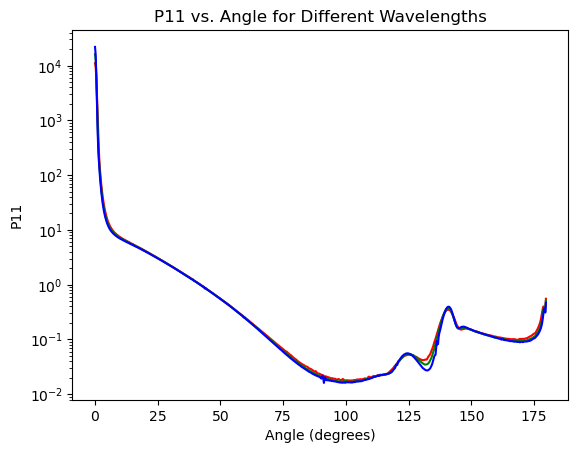

In [28]:
fig, ax= plt.subplots()

color_map = {'R': 'r', 'G': 'g', 'B': 'b'}    # Create a dictionary to map colors
re_value = 15.0
ve_value = 0.10
print(Cloud_Bulk_Scattering_Prop['B']['ve'])

# Calculate re_index based on re_array definition: np.arange(4, 40, 0.25)
re_index = int(round((re_value - 4) / 0.25))
print(re_index)

# Calculate ve_index based on ve_array definition: np.arange(0.01, 0.33, 0.01)
ve_index = int(round((ve_value - 0.01) / 0.01))
print(ve_index)

for color, data in Cloud_Bulk_Scattering_Prop.items():
    ax.plot(data['Angle'], data['P11'][re_index,ve_index,:], color=color_map[color], label=color)
    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('P11')
    ax.set_yscale('log')
    ax.set_title('P11 vs. Angle for Different Wavelengths')
    # ax.legend()
    
plt.show()

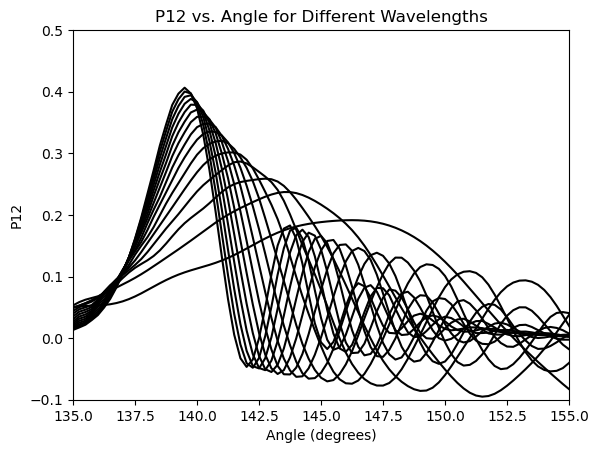

In [29]:
fig, ax= plt.subplots()
color_map = {'R': 'r', 'G': 'g', 'B': 'b'} # Create a dictionary to map colors
for i in range(0, len(re_array), 10):
    ax.plot(Cloud_Bulk_Scattering_Prop['R']['Angle'], -Cloud_Bulk_Scattering_Prop['R']['P12'][i,0,:], color='k') 
    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('P12')
    ax.set_xlim([135,155])
    ax.set_ylim([-0.1,0.5])
    ax.set_title('P12 vs. Angle for Different Wavelengths')
    # ax.legend()
    
plt.show()

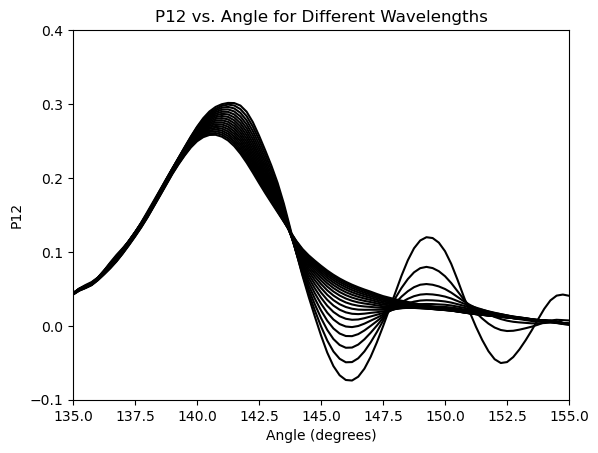

In [30]:
fig, ax= plt.subplots()
color_map = {'R': 'r', 'G': 'g', 'B': 'b'} # Create a dictionary to map colors
for i in range(0, len(ve_array), 2):
    ax.plot(Cloud_Bulk_Scattering_Prop['R']['Angle'], -Cloud_Bulk_Scattering_Prop['R']['P12'][40,i,:], color='k')
    ax.set_xlabel('Angle (degrees)')
    ax.set_ylabel('P12')
    ax.set_xlim([135,155])
    ax.set_ylim([-0.1,0.4])
    ax.set_title('P12 vs. Angle for Different Wavelengths')
    # ax.legend()
    
plt.show()

In [31]:
import pickle

file_path = 'cloud_bulk_scattering_prop.pkl'
with open(file_path, 'wb') as f:
    pickle.dump(Cloud_Bulk_Scattering_Prop, f)

print(f"'Cloud_Bulk_Scattering_Prop' saved successfully to {file_path}")

'Cloud_Bulk_Scattering_Prop' saved successfully to cloud_bulk_scattering_prop.pkl


In [32]:
# Cloud_Bulk_Scattering_Prop.keys()

In [33]:
# print(Cloud_Bulk_Scattering_Prop)

In [35]:
import pickle
import netCDF4

# load the pickle file
with open("cloud_bulk_scattering_prop.pkl", "rb") as f:
    lut = pickle.load(f)

bands = ["R", "G", "B"]

ds = netCDF4.Dataset("cloud_bulk_scattering_prop.nc", "w", format="NETCDF4")

# dimensions
ds.createDimension("band", len(bands))
ds.createDimension("re",   len(lut["R"]["re"]))
ds.createDimension("ve",   len(lut["R"]["ve"]))
ds.createDimension("angle", len(lut["R"]["Angle"]))

# coordinates
band = ds.createVariable("band", "i4", ("band",))
band[:] = np.arange(len(bands))

re = ds.createVariable("re", "f4", ("re",))
re[:] = lut["R"]["re"]

ve = ds.createVariable("ve", "f4", ("ve",))
ve[:] = lut["R"]["ve"]

angle = ds.createVariable("angle", "f4", ("angle",))
angle[:] = lut["R"]["Angle"]

P11 = ds.createVariable("P11", "f4", ("band", "re", "ve", "angle"))
P12 = ds.createVariable("P12", "f4", ("band", "re", "ve", "angle"))

for ib, b in enumerate(bands):
    P11[ib]  = lut[b]["P11"]
    P12[ib]  = lut[b]["P12"]

ds.close()
print("Saved cloud_bulk_scattering_prop.nc")

Saved cloud_bulk_scattering_prop.nc
